# 图像缩放实验练习版：坐标映射、最近邻插值与双线性插值

本 notebook 是学生练习版本。你需要补全图像缩放中的关键函数，实现横纵不同缩放比例下的图像缩小和放大。

要求：

- 支持横向缩放比例 `scale_x` 和纵向缩放比例 `scale_y` 不同。
- 缩小时实现区域平均方法。
- 放大时实现最近邻插值和双线性插值。
- 自己完成坐标映射和插值计算，不调用第三方库的 `resize` 函数。
- 绘图标题使用英文。

## 图像缩放相关知识

设原图像大小为 $H \times W$，横向缩放比例为 $s_x$，纵向缩放比例为 $s_y$，目标图像大小为：

$$W' = \text{round}(W \cdot s_x), \quad H' = \text{round}(H \cdot s_y)$$

缩放通常采用反向映射：对目标图像中的每一个像素，找到它在原图像中对应的位置，再计算目标像素值。

常用的像素中心对齐映射为：

$$x = \frac{x' + 0.5}{s_x} - 0.5$$

$$y = \frac{y' + 0.5}{s_y} - 0.5$$

### 缩小时的映射

缩小时，一个目标像素通常对应原图中的一个区域。目标像素 $(x', y')$ 在原图中覆盖的范围可近似为：

$$x_{start}=\frac{x'}{s_x}, \quad x_{end}=\frac{x'+1}{s_x}$$

$$y_{start}=\frac{y'}{s_y}, \quad y_{end}=\frac{y'+1}{s_y}$$

区域平均方法会对该范围内的原图像素求平均，作为目标像素值。这样比直接使用最近邻更不容易产生混叠。

### 放大时的最近邻插值

最近邻插值将目标像素映射回原图浮点坐标 $(x, y)$ 后，直接取最近的整数像素：

$$x_n = \text{round}(x), \quad y_n = \text{round}(y)$$

$$I'(x', y') = I(x_n, y_n)$$

快速寻找最近邻的提示：图像像素位于规则网格上，不需要计算到所有像素的距离；直接对浮点坐标四舍五入即可，再用边界裁剪保证坐标在合法范围内。

### 放大时的双线性插值

双线性插值使用映射点周围 4 个像素加权平均。设：

$$x_0=\lfloor x \rfloor, \quad x_1=x_0+1$$

$$y_0=\lfloor y \rfloor, \quad y_1=y_0+1$$

$$a=x-x_0, \quad b=y-y_0$$

则：

$$I'(x',y')=(1-a)(1-b)I(x_0,y_0)+a(1-b)I(x_1,y_0)+(1-a)bI(x_0,y_1)+abI(x_1,y_1)$$

最近邻速度快但块状感明显；双线性插值更平滑，但边缘可能略微模糊。

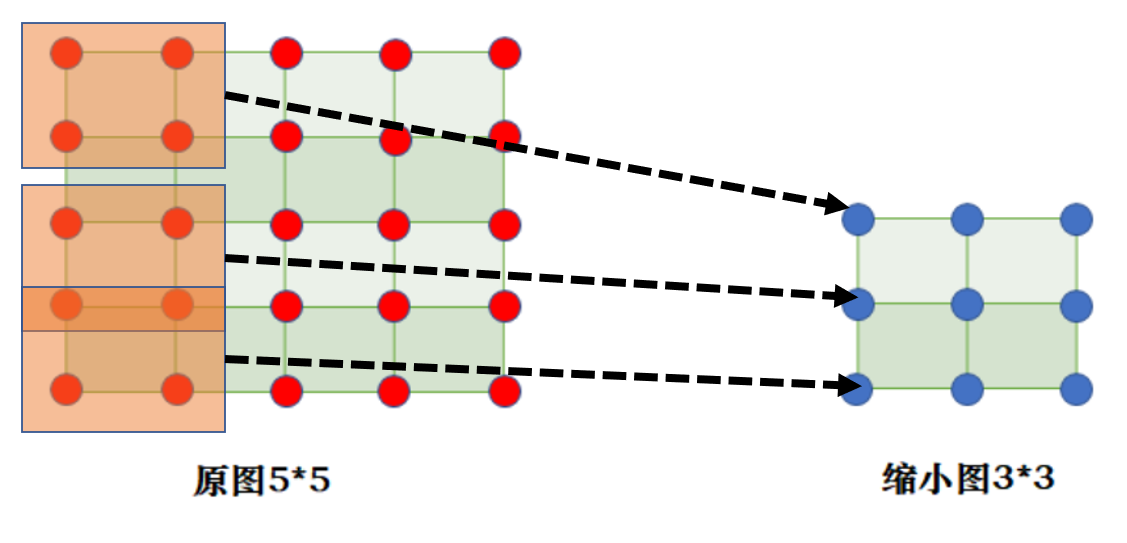


## 公共代码

请先补全 `compute_output_size` 和 `source_coordinate`，后面的缩放函数都依赖它们。

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, io
from skimage.color import rgba2rgb


def load_image():
    """优先读取当前目录下的 Lena 图像；如果没有，则使用内置图像作为备用。"""
    candidate_paths = [
        Path("lena.png"), Path("lena.jpg"), Path("lena.jpeg"), Path("lena.bmp"),
        Path("Lena.png"), Path("Lena.jpg"), Path("Lena.jpeg"), Path("Lena.bmp"),
        Path("lenna.png"), Path("lenna.jpg"), Path("lenna.jpeg"), Path("lenna.bmp"),
    ]

    for path in candidate_paths:
        if path.exists():
            image = img_as_float(io.imread(path))
            break
    else:
        image = img_as_float(data.astronaut())

    if image.ndim == 3 and image.shape[-1] == 4:
        image = rgba2rgb(image)
    return image


def ensure_3d(image):
    """将灰度图临时转换为 H x W x 1，便于统一处理。"""
    if image.ndim == 2:
        return image[..., np.newaxis], True
    return image, False


def restore_shape(image, was_gray):
    """如果原图是灰度图，则去掉最后一个通道维度。"""
    if was_gray:
        return image[..., 0]
    return image


def compute_output_size(image, scale_x, scale_y):
    """根据缩放比例计算目标图像尺寸。

    学生需要补全：
    1. 检查 scale_x 和 scale_y 是否为正数。
    2. 读取原图高度 height 和宽度 width。
    3. 计算 new_width = round(width * scale_x)。
    4. 计算 new_height = round(height * scale_y)。
    5. 使用 max(1, ...) 保证目标宽高至少为 1。
    6. 返回 new_height, new_width。
    """
    # TODO：请补全目标尺寸计算。
    raise NotImplementedError("请补全 compute_output_size。")


def source_coordinate(target_index, scale):
    """将目标像素中心映射回原图坐标。

    学生需要补全：
    1. 使用像素中心对齐公式。
    2. 公式为 (target_index + 0.5) / scale - 0.5。
    3. 返回映射后的浮点源坐标。
    """
    # TODO：请补全坐标映射公式。
    raise NotImplementedError("请补全 source_coordinate。")


def show_images(images, titles, cols=3):
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 4.0 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, image, title in zip(axes, images, titles):
        ax.imshow(np.clip(image, 0, 1), cmap="gray" if image.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


image = load_image()
show_images([image], ["Original Image"], cols=1)

## 代码段 1：图像缩小：区域平均方法

请补全 `resize_area_average`。

大致步骤：

1. 使用 `ensure_3d` 统一处理灰度图和彩色图。
2. 通过 `compute_output_size` 得到目标高度和宽度。
3. 遍历目标图像的每个像素。
4. 根据 `target_x / scale_x` 和 `(target_x + 1) / scale_x` 找到原图 x 方向覆盖范围。
5. 根据 `target_y / scale_y` 和 `(target_y + 1) / scale_y` 找到原图 y 方向覆盖范围。
6. 使用 `floor`、`ceil` 和 `clip` 得到合法整数区域。
7. 对该原图区域求平均，作为目标像素值。
8. 使用 `restore_shape` 恢复灰度图形状。

In [ ]:
def resize_area_average(image, scale_x=0.5, scale_y=0.5):
    """使用区域平均方法缩小图像。"""
    # TODO：请根据上面的步骤补全区域平均缩小方法。
    raise NotImplementedError("请补全 resize_area_average。")


# ===== 可调实验参数 =====
scale_x = 0.45
scale_y = 0.65

downscaled = resize_area_average(image, scale_x=scale_x, scale_y=scale_y)
show_images(
    [image, downscaled],
    ["Original Image", f"Downscale Area Average sx={scale_x}, sy={scale_y}"],
    cols=2
)

## 代码段 2：图像放大：最近邻插值

请补全 `resize_nearest_neighbor`。

大致步骤：

1. 使用 `compute_output_size` 创建目标图像。
2. 遍历每个目标像素。
3. 使用 `source_coordinate` 将目标坐标映射回原图浮点坐标。
4. 使用 `round` 快速找到最近的整数像素坐标。
5. 使用 `np.clip` 防止坐标越界。
6. 将最近邻原像素值赋给目标像素。
7. 恢复灰度图形状并返回结果。

提示：因为像素在规则网格上，所以最近邻坐标可以直接由四舍五入得到，不需要计算到所有像素的距离。

In [ ]:
def resize_nearest_neighbor(image, scale_x=2.0, scale_y=2.0):
    """使用最近邻插值缩放图像。"""
    # TODO：请根据上面的步骤补全最近邻插值。
    raise NotImplementedError("请补全 resize_nearest_neighbor。")


# ===== 可调实验参数 =====
scale_x = 1.8
scale_y = 1.3

nearest_scaled = resize_nearest_neighbor(image, scale_x=scale_x, scale_y=scale_y)
show_images(
    [image, nearest_scaled],
    ["Original Image", f"Nearest Neighbor sx={scale_x}, sy={scale_y}"],
    cols=2
)

## 代码段 3：图像放大：双线性插值

请补全 `resize_bilinear`。

大致步骤：

1. 遍历目标图像中的每个像素。
2. 使用 `source_coordinate` 得到原图浮点坐标 `(src_x, src_y)`。
3. 使用 `floor` 得到左上角坐标 `(x0, y0)`。
4. 使用 `x1 = x0 + 1`、`y1 = y0 + 1` 得到右下邻居，并处理边界。
5. 计算小数部分 `a = src_x - x0`、`b = src_y - y0`。
6. 取出左上、右上、左下、右下 4 个像素。
7. 使用双线性插值公式加权求和。
8. 恢复灰度图形状并返回结果。

In [ ]:
def resize_bilinear(image, scale_x=2.0, scale_y=2.0):
    """使用双线性插值缩放图像。"""
    # TODO：请根据上面的步骤补全双线性插值。
    raise NotImplementedError("请补全 resize_bilinear。")


# ===== 可调实验参数 =====
scale_x = 1.8
scale_y = 1.3

bilinear_scaled = resize_bilinear(image, scale_x=scale_x, scale_y=scale_y)
show_images(
    [image, nearest_scaled, bilinear_scaled],
    ["Original Image", "Nearest Neighbor", "Bilinear Interpolation"],
    cols=3
)

## 代码段 4：灰度示意图放大实验

请补全 `create_gray_ramp`，构造一个灰度值从左下角到右上角逐渐增大的小尺寸灰度图，然后用最近邻和双线性插值进行放大。

大致步骤：

1. 生成 x 方向从左到右逐渐增大的数组。
2. 生成 y 方向从下到上逐渐增大的数组。注意图像数组的第 0 行显示在最上方。
3. 将 x 方向趋势和 y 方向趋势相加并归一化到 `[0, 1]`。
4. 返回二维灰度矩阵。
5. 分别调用最近邻和双线性插值函数放大该灰度图。

观察：最近邻放大后会有明显块状台阶；双线性插值放大后灰度变化更平滑。

In [ ]:
def create_gray_ramp(height=6, width=6):
    """创建从左下角到右上角逐渐变亮的灰度示意图。"""
    # TODO：请补全灰度示意图生成。
    raise NotImplementedError("请补全 create_gray_ramp。")


def show_gray_values(image, title):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(np.arange(image.shape[1]))
    ax.set_yticks(np.arange(image.shape[0]))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color="red", linewidth=0.8)

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            value = image[row, col]
            text_color = "black" if value > 0.55 else "white"
            ax.text(col, row, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=9)

    plt.tight_layout()
    plt.show()


# ===== 示意图实验参数 =====
demo_scale_x = 4.0
demo_scale_y = 4.0

gray_ramp = create_gray_ramp(height=6, width=6)
gray_nearest = resize_nearest_neighbor(gray_ramp, scale_x=demo_scale_x, scale_y=demo_scale_y)
gray_bilinear = resize_bilinear(gray_ramp, scale_x=demo_scale_x, scale_y=demo_scale_y)

show_gray_values(gray_ramp, "Original Gray Ramp Values")
show_images(
    [gray_ramp, gray_nearest, gray_bilinear],
    ["Original Gray Ramp", "Nearest Neighbor Ramp", "Bilinear Ramp"],
    cols=3
)

## 检查建议

完成代码后，可以按下面方式检查：

- `compute_output_size` 对不同 `scale_x`、`scale_y` 能返回合理的新尺寸。
- `source_coordinate(0, 2.0)` 应映射到靠近原图第一个像素中心的位置。
- 缩小时，区域平均结果应比最近邻更平滑。
- 放大时，最近邻结果应有明显块状感。
- 放大时，双线性插值结果应比最近邻更平滑。
- 灰度示意图应从左下角到右上角逐渐变亮。